[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leonardijulia/AGAI_practice/blob/main/AlphaEarth_GEE/AE_Exercises.ipynb)

# Imports

In [41]:
import ee
import geemap
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

import ipywidgets as widgets
from IPython.display import display

# Authenticate to GEE and connect to GDrive
To Authenticate and Initialize your GEE project and thus have access to the GEE data catalog you need to first have
  1) A google account
  2) A GEE account with a valid non commercial project

In [2]:
ee.Authenticate()
ee.Initialize(project='lithe-timer-424608-c4')

drive.mount("/content/drive/")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Mounted at /content/drive/


# 1. Explore the AlphaEarth collection

In [3]:
# Access the Satelite Embedding dataset
collection = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')

# Let's see what an ImageCollection object contains and display the metadata of the first element fetched
# NOTE:
# print(obj) reads client-side only (showing a raw, unreadable server-pointer JSON).
# display(obj) automatically fetches server-side data into a rich Jupyter notebook view.
display(collection.limit(1))


More technical details about the data: https://developers.google.com/earth-engine/guides/aef_on_gcs_readme

In [4]:
# Select a region
polygon = ee.Geometry.Polygon([
    [
        [20.7130, 52.3946],  # Northwest corner
        [21.4155, 52.3946],  # Northeast corner
        [21.4155, 52.0775],  # Southeast corner
        [20.7130, 52.0775],  # Southwest corner
        [20.7130, 52.3946]   # Close the polygon ring back at the NW corner
    ]
  ]) # Warsaw, Poland (feel free to change the region and explore your favorite place :))

# Let's see the embedding fields for two consecutive years and compare them
# 2023 embeddings
image1 = collection \
      .filterDate('2023-01-01', '2024-01-01') \
      .filterBounds(polygon) \
      .mosaic() \
      .clip(polygon) # We can also clip the image
# We get multiple Satellite Embedding tiles covering the ROI
# We can use .mosaic() to combine multiple tiles into a single image

# 2024 embeddings
image2 = collection \
      .filterDate('2024-01-01', '2025-01-01') \
      .filterBounds(polygon) \
      .mosaic() \
      .clip(polygon)

In [5]:
display(image1.bandNames())

In [6]:
# The embedding field contains 64 bands, so it's not easy to visualize all teh information
# We can only see a combination of three bands at a time!
# Let's pick three bands to visualize three axes of the embedding space as an "RGB" image.
visParams = {'min'   : -0.3,
             'max'   : 0.3,
             'bands' : ['A08', 'A62', 'A16']}

### Visualize

In [7]:
# One tile ~ 164x164 km
map = geemap.Map(basemap='HYBRID', center=[52.2298, 21.0118], zoom=10)
map.addLayer(image1, visParams, '2023 EMB')
map.addLayer(image2, visParams, '2024 EMB')
map.addLayer(polygon, {'color': 'green', 'alpha': 0.5}, 'Warsaw Polygon')
display(map)

Map(center=[52.2298, 21.0118], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

### Compute the similarity between embedding vectors

The embeddings are **unit-length**, meaning they have a magnitude of 1 and do not require any additional normalization, and are distributed across the unit sphere. With this property, computing the dot product will simplify to the cosine of the angle between the embedding vectors.

**Geometric formula of the dot product**:

$$\mathbf{u} \cdot \mathbf{v} = \|\mathbf{u}\| \|\mathbf{v}\| \cos\theta$$

$\|\mathbf{u}\| = 1$ and $\|\mathbf{v}\| = 1$.

In [8]:
# .multiply() does element-wise multiplication for each band (A1*B1, A2*B2, etc.).
# .reduce(ee.Reducer.sum()) sums all those band products together to complete the dot product.
dot_prod = image1 \
    .multiply(image2) \
    .reduce(ee.Reducer.sum())

map.addLayer(
    dot_prod,
    {'min': 0, 'max': 1, 'palette': ['white', 'black']},
    'Similarity between years (brighter = less similar)'
)
display(map)

Map(bottom=86618.0, center=[52.2298, 21.0118], controls=(WidgetControl(options=['position', 'transparent_bg'],…

# 2. Clustering

We can also try and understand how the model has learnt the spatial and temporal variability of the landscape, by visualizing clusters of similar embeddings.

In [ ]:
# Let's sample 1000 embeddings from our region of interest (year 2023)
n_samples = 1000
training = image1.sample(**{
    'region': polygon,
    'scale': 10,
    'numPixels': n_samples,
    'seed': 42
})

In [ ]:
# Explore the values of the first training sample
first_sample = training.first()
bands = first_sample.getInfo()['properties']
vector = np.array(list(bands.values()), dtype=float)

# Let's check out if the vector has a unit length
magnitude = np.linalg.norm(vector)
print(f"The embedding vector length fromthe origin to the values of the vector is: {magnitude}")

The embedding vector length fromthe origin to the values of the vector is: 1.0014114706445898


Google employs quantization mapping to compress raw deep learning embeddings before storing them as Cloud Optimized GeoTIFFs, which causes slight precision loss and accumulated rounding errors when fetched via Python. More info: https://developers.google.com/earth-engine/guides/aef_on_gcs_readme

In [ ]:
def get_clusters(n_clusters: int):
  clusterer = ee.Clusterer.wekaKMeans(n_clusters).train(training)
  image_clusters = image1.cluster(clusterer)
  return image_clusters

In [ ]:
three_clusters = get_clusters(3)
map.addLayer(three_clusters.randomVisualizer().clip(polygon), {}, '3 clusters')
display(map)

Map(bottom=86613.0, center=[52.23368724057246, 21.0497828989223], controls=(WidgetControl(options=['position',…

In [ ]:
ten_clusters = get_clusters(10)
map.addLayer(ten_clusters.randomVisualizer().clip(polygon), {}, '10 clusters')
display(map)

Map(bottom=86588.0, center=[52.25470880113083, 21.110217041571687], controls=(WidgetControl(options=['position…

# 3. Supervised Classification

AE embeddings were specifically designed for low-shot learning, meaning that we need a relatively small number of labeled data to achieve high-quality classification results (10s to 100s of samples vs 1000+ for any other decent DL algorithm using raw data).

In [ ]:
#TODO: Manual sampling and training a RF model

# 4. Regression

In [59]:
roi = ee.Geometry.BBox(74.322, 14.765, 74.648, 14.981)

start_date = '2022-01-01'
end_date = '2022-12-31'

embeddings = (
    ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
    .filterDate(start_date, end_date)
    .filterBounds(roi)
    .mosaic()
    .clip(roi)
)

gedi_col = (
    ee.ImageCollection('LARSE/GEDI/GEDI04_A_002_MONTHLY')
    .filterDate(start_date, end_date)
    .filterBounds(roi)
)

def filter_gedi(img):
    quality = img.select('l4_quality_flag').eq(1).And(img.select('degrade_flag').eq(0))
    low_error = img.select('agbd_se').divide(img.select('agbd')).lte(0.5)
    return img.updateMask(quality.And(low_error))

gedi_agbd = gedi_col.map(filter_gedi).select('agbd').mosaic().clip(roi)

In [60]:
gedi_valid_mask = gedi_agbd.mask().toInt().rename('has_gedi')
stacked = embeddings.addBands(gedi_agbd).addBands(gedi_valid_mask)

num_samples = 1000
samples = stacked.stratifiedSample(
    numPoints=num_samples,
    classBand='has_gedi',
    region=roi,
    scale=30,           # Sample at GEDI footprint scale
    classValues=[0, 1],
    classPoints=[1, num_samples],
    tileScale=4,
    dropNulls=True,
    geometries=False    # Speeds up conversion to table
)

df = geemap.ee_to_df(samples)
print(f"Sampled {len(df)} points successfully.")
display(df.head(3))

Sampled 1001 points successfully.


,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,A56,A57,A58,A59,A60,A61,A62,A63,agbd,has_gedi
0,0.088827,-0.027128,0.251965,-0.019931,-0.055363,-0.051734,-0.135886,0.113741,0.027128,0.019931,...,0.019931,-0.051734,-0.172795,-0.079723,-0.055363,-0.153787,0.088827,0.048228,64.997627,0
1,0.055363,-0.093564,0.147697,0.008858,-0.055363,-0.066990,-0.199862,0.179377,0.048228,0.019931,...,0.010396,-0.038447,-0.059116,-0.017778,0.093564,-0.166336,0.166336,0.108512,273.593231,1
2,0.079723,-0.044844,0.119093,0.015748,-0.041584,-0.071111,-0.166336,0.153787,-0.029773,0.041584,...,0.013841,-0.035433,-0.108512,-0.130165,0.108512,-0.153787,0.055363,0.084214,91.560417,1


In [61]:
predictor_cols = [c for c in df.columns if c.startswith('A') or c.isdigit()]
target_col = 'agbd'

X = df[predictor_cols]
y = df[target_col]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [62]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f} Mg/ha")
print(f"Test R^2:  {r2:.3f}")

Test RMSE: 61.96 Mg/ha
Test R^2:  0.214


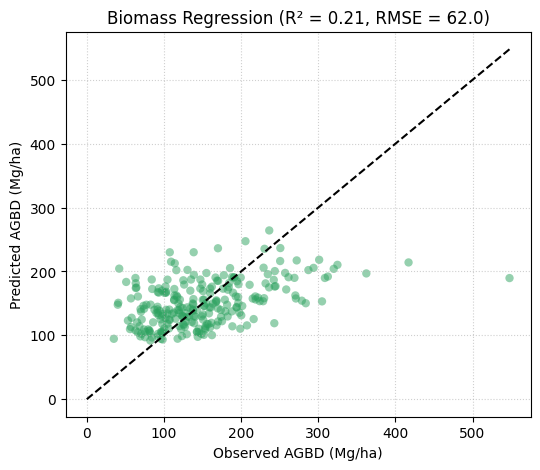

In [63]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='none', color='#2ca25f')
plt.plot([0, max(y_test)], [0, max(y_test)], '--k', lw=1.5)
plt.xlabel('Observed AGBD (Mg/ha)')
plt.ylabel('Predicted AGBD (Mg/ha)')
plt.title(f'Biomass Regression (R² = {r2:.2f}, RMSE = {rmse:.1f})')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [64]:
gee_model = (
    ee.Classifier.smileRandomForest(50)
    .setOutputMode('REGRESSION')
    .train(
        features=samples,
        classProperty='agbd',
        inputProperties=embeddings.bandNames()
    )
)

In [66]:
predicted_surface = embeddings.classify(gee_model, 'agbd_pred')
map = geemap.Map(basemap='HYBRID')
map.centerObject(roi, 12)

gedi_vis = {'min': 0, 'max': 250, 'palette': ['#edf8fb', '#b2e2e2', '#66c2a4', '#2ca25f', '#006d2c']}
map.addLayer(gedi_agbd, gedi_vis, 'GEDI Sparse Points')
map.addLayer(predicted_surface, gedi_vis, 'Predicted Continuous Biomass (Wall-to-Wall)')
map.add_colorbar(gedi_vis, label='Biomass (Mg/ha)', layer_name='Predicted Biomass', orientation='horizontal', position='bottomright')
map.addLayerControl()
display(map)

Map(center=[14.873001153813972, 74.48500000000016], controls=(WidgetControl(options=['position', 'transparent_…

In [70]:
worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
worldcover_resampled = worldcover \
  .reduceResolution(**{
    'reducer': ee.Reducer.mode(),
    'maxPixels': 1024
  })
land_cover_mask = worldcover_resampled.eq(10) \
  or worldcover_resampled.eq(20) \
  or(worldcover_resampled.eq(30)) \
  or(worldcover_resampled.eq(40)) \
  or(worldcover_resampled.eq(95))

predicted_image_masked = predicted_surface.updateMask(land_cover_mask)
map.addLayer(predicted_image_masked, gedi_vis, 'Predicted Biomass (masked)')
display(map)

Map(bottom=960847.0, center=[14.938979875240605, 74.5930477066214], controls=(WidgetControl(options=['position…

In [74]:
pixel_area_ha = ee.Image.pixelArea().divide(10000)
predicted_agb = predicted_image_masked.multiply(pixel_area_ha).reduceRegion(**{
    'reducer': ee.Reducer.sum(),
    'geometry': roi,
    'scale': 30,
    'maxPixels': 1e13
})
print(f"Predicted AGB: {predicted_agb.getInfo()['agbd_pred']} Mg/ha")

Predicted AGB: 11445527.07854086 Mg/ha


# 5. Similarity Search

In [75]:
search_region = ee.Geometry.BBox(-0.51, 51.35, 0.25, 51.68)
ref_points = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-0.2796, 51.5560]), {'name': 'Wembley'}),
    ee.Feature(ee.Geometry.Point([-0.0664, 51.6042]), {'name': 'Tottenham'})
])

year = 2023
embeddings = (
    ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
    .filterDate(f'{year}-01-01', f'{year}-12-31')
    .filterBounds(search_region)
    .mosaic()
    .clip(search_region)
)

In [76]:
ref_samples = embeddings.sampleRegions(
    collection=ref_points,
    scale=10,
    geometries=False
)

band_names = embeddings.bandNames()
mean_dict = ref_samples.reduceColumns(
    reducer=ee.Reducer.mean().repeat(band_names.size()),
    selectors=band_names
)

In [77]:
mean_list = ee.List(mean_dict.get('mean'))
ref_vector_image = ee.Image.constant(mean_list).rename(band_names)

In [78]:
similarity = (
    embeddings.multiply(ref_vector_image)
    .reduce(ee.Reducer.sum())
    .rename('cosine_similarity')
)

threshold = 0.85
matches = similarity.gte(threshold).selfMask()

In [80]:
clusters = matches.connectedPixelCount(100, False)
stadium_candidates = matches.updateMask(clusters.gte(15))
vectors = stadium_candidates.reduceToVectors(
    geometry=search_region,
    crs=embeddings.projection(),
    scale=20,
    geometryType='centroid',
    eightConnected=True,
    maxPixels=1e8
)

print(f"Detected candidates count: {vectors.size().getInfo()}")

Detected candidates count: 4


In [81]:
map = geemap.Map(basemap='HYBRID')
map.centerObject(search_region, 10)
sim_vis = {
    'min': 0.60,
    'max': 0.95,
    'palette': ['#313695', '#4575b4', '#74add1', '#ffffbf', '#f46d43', '#d73027']
}

# 1. Similarity heatmap
map.addLayer(similarity, sim_vis, 'Stadium Cosine Similarity', opacity=0.7)

# 2. Thresholded matches (Bright yellow highlights)
map.addLayer(matches, {'palette': ['#ffff00']}, f'Matches (Score >= {threshold})')

# 3. Reference locations (Cyan markers)
map.addLayer(ref_points, {'color': 'cyan'}, 'Reference Stadiums')

# 4. Detected Centroids (Red markers)
map.addLayer(vectors, {'color': 'red'}, 'Detected Stadium Centroids')

# Continuous colorbar legend
map.add_colorbar(
    vis_params=sim_vis,
    label='Cosine Similarity to Stadium Prototype',
    orientation='horizontal',
    position='bottomright'
)

map.addLayerControl()
display(map)

Map(center=[51.5150053866539, -0.13000000000027226], controls=(WidgetControl(options=['position', 'transparent…

If you want to further explore similarity between locations, check out: https://earthengine-ai.projects.earthengine.app/view/embedding-similarity-search#year=2025